# Titanic Survival Logic


# Titanic Survival Logic

In this notebook, I will clean the Titanic dataset, analyze survival rates, create new features, and build a simple manual heuristic model using if/else statements.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print("Libraries imported successfully")

Libraries imported successfully


## Load the Dataset

First, I will load the Titanic dataset and inspect it.

In [2]:
# Load Titanic dataset
df = pd.read_csv("dataset-2.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Dataset info
print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

Shape of dataset: (891, 12)

Columns:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


## Task 1: The Missing Age

The Age column has missing values.  
I will calculate the median age and fill the missing values with the median.

The median is often better than the mean because it is less affected by outliers.
For example, if a few passengers are very old, the mean age can become too high, while the median stays more representative of the middle.

In [4]:
# Median age
median_age = df["Age"].median()
print("Median Age:", median_age)

Median Age: 28.0


In [5]:
# Fill missing Age values
df["Age"] = df["Age"].fillna(median_age)

print("Missing values in Age after filling:", df["Age"].isnull().sum())

Missing values in Age after filling: 0


## Task 2: Dropping the Noise

Some columns are not very useful for this analysis:
- Cabin: too many missing values
- Ticket: not useful for statistical analysis
- Name and PassengerId: identifiers, not useful for prediction here

In [6]:
# Drop unnecessary columns
df = df.drop(["Cabin", "Ticket", "Name", "PassengerId"], axis=1)

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [7]:
# Fill missing Embarked values if any
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

print(df.isnull().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


## Task 3: Gender and Survival

Now I will calculate survival rates for males and females.

In [8]:
# Survival rate by gender
gender_survival = df.groupby("Sex")["Survived"].mean()
print(gender_survival)

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


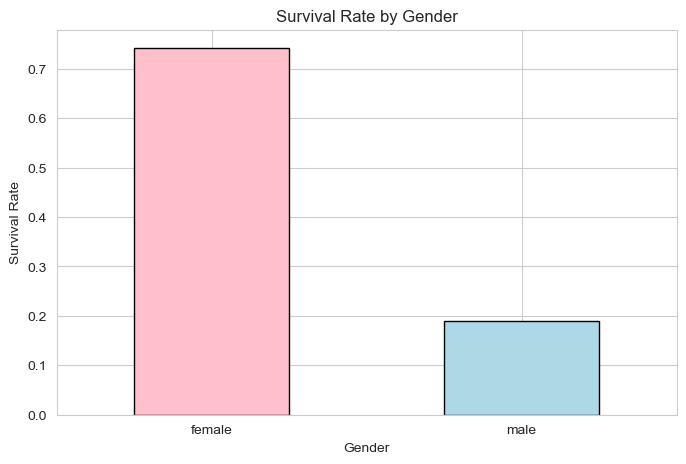

In [9]:
# Bar chart for survival rate by gender
plt.figure(figsize=(8,5))
gender_survival.plot(kind="bar", color=["pink", "lightblue"], edgecolor="black")

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.xticks(rotation=0)
plt.show()

## Task 4: Survival by Passenger Class

Now I will calculate survival rate for each passenger class.

In [10]:
# Survival rate by class
class_survival = df.groupby("Pclass")["Survived"].mean()
print(class_survival)

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


In [11]:
# Difference between 1st and 3rd class
first_class_rate = class_survival[1]
third_class_rate = class_survival[3]

difference = first_class_rate - third_class_rate

print("1st class survival rate:", first_class_rate)
print("3rd class survival rate:", third_class_rate)
print("Difference:", difference)
print("3rd class passengers had", difference * 100, "% lower survival chance than 1st class passengers.")

1st class survival rate: 0.6296296296296297
3rd class survival rate: 0.24236252545824846
Difference: 0.3872671041713812
3rd class passengers had 38.72671041713812 % lower survival chance than 1st class passengers.


## Task 5: Age Demographics

I will create a KDE plot to compare age distribution of survivors and non-survivors.
This helps check if there is a child survival pattern.

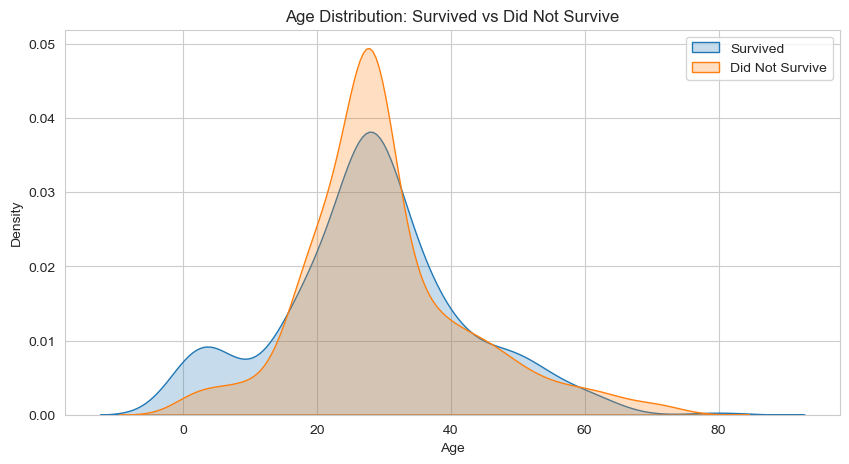

In [12]:
# KDE plot
plt.figure(figsize=(10,5))

sns.kdeplot(df[df["Survived"] == 1]["Age"], label="Survived", fill=True)
sns.kdeplot(df[df["Survived"] == 0]["Age"], label="Did Not Survive", fill=True)

plt.title("Age Distribution: Survived vs Did Not Survive")
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend()
plt.show()

### Insight

If the survivor curve is higher for young ages, that suggests children had better survival chances.

In [13]:
# Survival rate for children
children = df[df["Age"] < 10]
print("Children survival rate:", children["Survived"].mean())
print("Overall survival rate:", df["Survived"].mean())

Children survival rate: 0.6129032258064516
Overall survival rate: 0.3838383838383838


## Task 6: FamilySize Feature

I will create a new column called FamilySize by adding SibSp and Parch.

In [14]:
# Create FamilySize
df["FamilySize"] = df["SibSp"] + df["Parch"]

df[["SibSp", "Parch", "FamilySize"]].head()

,SibSp,Parch,FamilySize
0,1,0,1
1,1,0,1
2,0,0,0
3,1,0,1
4,0,0,0


## Task 7: Alone vs Accompanied

Now I will create a binary column called IsAlone.

- If FamilySize = 0, the passenger is alone
- Otherwise, the passenger is with family

In [15]:
# Create IsAlone
df["IsAlone"] = 0
df.loc[df["FamilySize"] == 0, "IsAlone"] = 1

df[["FamilySize", "IsAlone"]].head()

,FamilySize,IsAlone
0,1,0
1,1,0
2,0,1
3,1,0
4,0,1


In [16]:
# Survival rate for alone vs not alone
alone_survival = df.groupby("IsAlone")["Survived"].mean()
print(alone_survival)

IsAlone
0    0.505650
1    0.303538
Name: Survived, dtype: float64


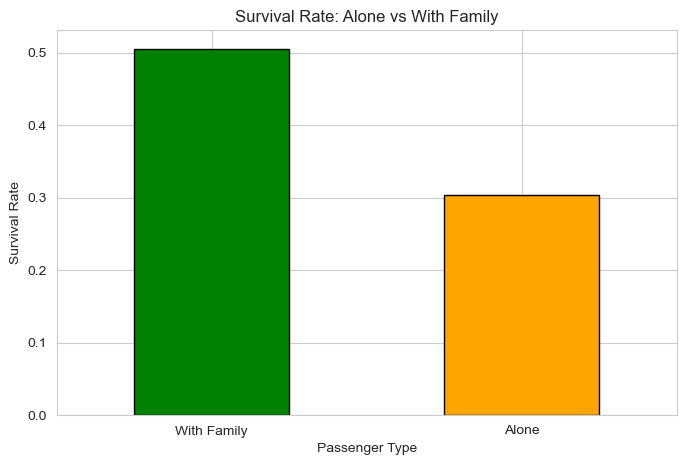

In [17]:
# Bar chart
plt.figure(figsize=(8,5))
alone_survival.index = ["With Family", "Alone"]
alone_survival.plot(kind="bar", color=["green", "orange"], edgecolor="black")

plt.title("Survival Rate: Alone vs With Family")
plt.xlabel("Passenger Type")
plt.ylabel("Survival Rate")
plt.xticks(rotation=0)
plt.show()

## Task 8: Manual Heuristic Model

Now I will build a simple prediction function using if/else statements.
I will not use machine learning libraries for this task.

My simple logic:
- If the passenger is female, predict survived
- If the passenger is a male child, predict survived
- Otherwise, predict not survived

In [18]:
# Heuristic function
def predict_survival(row):
    if row["Sex"] == "female":
        return 1
    elif row["Sex"] == "male" and row["Age"] < 10:
        return 1
    else:
        return 0

## Task 9: Accuracy Check

Now I will apply my manual prediction function to the entire dataset and calculate the accuracy.

In [19]:
# Apply prediction function
df["Prediction"] = df.apply(predict_survival, axis=1)

df[["Sex", "Age", "Survived", "Prediction"]].head()

,Sex,Age,Survived,Prediction
0,male,22.0,0,0
1,female,38.0,1,1
2,female,26.0,1,1
3,female,35.0,1,1
4,male,35.0,0,0


In [20]:
# Calculate accuracy
correct_predictions = (df["Prediction"] == df["Survived"]).sum()
total_predictions = len(df)

accuracy = correct_predictions / total_predictions

print("Correct predictions:", correct_predictions)
print("Total passengers:", total_predictions)
print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100)

Correct predictions: 707
Total passengers: 891
Accuracy: 0.7934904601571269
Accuracy Percentage: 79.34904601571269


## Conclusion

In this notebook, I cleaned the Titanic dataset, analyzed survival by gender, class, and age, created new family-related features, and built a simple heuristic model.  
The model used only if/else logic and still reached a strong accuracy because gender and age were strong survival indicators.